In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

### Dataset Overview

In [2]:
# Load the dataset
df = pd.read_csv('ecological_health_dataset.csv')

print("\nDATASET OVERVIEW")
print("-"*70)
print(f"Dataset Shape: {df.shape}")
print(f"Total Samples: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nTarget Variable Distribution:")
print(df['Ecological_Health_Label'].value_counts())


DATASET OVERVIEW
----------------------------------------------------------------------
Dataset Shape: (61345, 16)
Total Samples: 61345
Total Features: 16

First 5 Rows:
       Timestamp       PM2.5  Temperature   Humidity  Soil_Moisture  \
0  1/1/2018 0:00  119.683970    21.885828  53.955603      22.479784   
1  1/1/2018 1:00   74.723237    19.079564  54.298952      23.980314   
2  1/1/2018 2:00   69.114179    26.675869  98.991222      11.566319   
3  1/1/2018 3:00   69.115115    20.170066  36.416460      36.144570   
4  1/1/2018 4:00  232.485721    21.915745  79.355625      43.532541   

   Biodiversity_Index  Nutrient_Level  Water_Quality  Air_Quality_Index  \
0                   9              50              0          82.594928   
1                   9               0              0         127.418484   
2                   7              50              0          95.215419   
3                  10               0              0          65.534270   
4                  11      

### Data Preprocessing

In [3]:
# Handling missing values
# Check missing values
print(df.isnull().sum())

print("\nTotal missing values: ")
print(df.isnull().sum().sum())

Timestamp                    0
PM2.5                        0
Temperature                  0
Humidity                     0
Soil_Moisture                0
Biodiversity_Index           0
Nutrient_Level               0
Water_Quality                0
Air_Quality_Index            0
Pollution_Level              0
Soil_pH                      0
Dissolved_Oxygen             0
Chemical_Oxygen_Demand       0
Biochemical_Oxygen_Demand    0
Total_Dissolved_Solids       0
Ecological_Health_Label      0
dtype: int64

Total missing values: 
0


In [4]:
# Handle Duplicate Rows
print("Duplicate Rows:")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed. New shape: {df.shape}")

Duplicate Rows:
Number of duplicate rows: 0


In [5]:
# Dropping time column
if 'Timestamp' in df.columns:
    df = df.drop('Timestamp', axis=1)
    print("Timestamp column dropped.")

Timestamp column dropped.


In [6]:
# Identify column types
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: \n{numerical_cols}\n")
print(f"Categorical columns: \n{categorical_cols}")

Numerical columns: 
['PM2.5', 'Temperature', 'Humidity', 'Soil_Moisture', 'Biodiversity_Index', 'Nutrient_Level', 'Water_Quality', 'Air_Quality_Index', 'Soil_pH', 'Dissolved_Oxygen', 'Chemical_Oxygen_Demand', 'Biochemical_Oxygen_Demand', 'Total_Dissolved_Solids']

Categorical columns: 
['Pollution_Level', 'Ecological_Health_Label']


In [7]:
# Check for impossible values first (negative Dissolved_Oxygen)
print("Negative Dissolved_Oxygen:", (df['Dissolved_Oxygen'] < 0).sum())
df['Dissolved_Oxygen'] = df['Dissolved_Oxygen'].clip(lower=0)  # Fix physically impossible

Negative Dissolved_Oxygen: 11


In [8]:
y = df['Ecological_Health_Label']
X = df.drop('Ecological_Health_Label', axis=1)

In [9]:
# Handle Outliers using IQR method
def handle_outliers_conservative(dataframe, columns, factor=3.0):  # 3.0 = very conservative
    """
    Handle only extreme outliers using IQR method with high threshold.
    Factor 3.0 catches only ~0.1% of data vs 1.5 catching ~5%
    """
    df_clean = dataframe.copy()
    outlier_info = {}
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Much wider bounds - only extreme outliers
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
        outlier_info[col] = len(outliers)
        
        # Only cap if bounds are reasonable (don't cap environmental extremes)
        if col in ['PM2.5', 'Chemical_Oxygen_Demand', 'Total_Dissolved_Solids']:
            # For pollution: cap only above 99th percentile, not below
            upper_cap = df_clean[col].quantile(0.99)
            df_clean[col] = df_clean[col].clip(upper=upper_cap)
            print(f"  {col}: Capped at 99th percentile ({upper_cap:.2f}), {len(df_clean[df_clean[col] > upper_cap])} values")
        else:
            # For other features: mild capping
            df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
    
    return df_clean, outlier_info

# Apply conservative outlier handling
feature_cols = [col for col in numerical_cols if col != 'Ecological_Health_Label']
df, outlier_counts = handle_outliers_conservative(df, feature_cols, factor=3.0)

  PM2.5: Capped at 99th percentile (334.40), 0 values
  Chemical_Oxygen_Demand: Capped at 99th percentile (296.94), 0 values
  Total_Dissolved_Solids: Capped at 99th percentile (494.75), 0 values


In [10]:
# Handle Inconsistent Data
print("\nUnique values in categorical columns:")
for col in categorical_cols:
    print(f"  {col}: {df[col].unique()}")


Unique values in categorical columns:
  Pollution_Level: ['Low' 'Moderate' 'High']
  Ecological_Health_Label: ['Ecologically Healthy' 'Ecologically Stable' 'Ecologically Critical'
 'Ecologically Degraded']


In [11]:
# Check target variable distribution
print(f"\nTarget Variable Distribution:")
print(df['Ecological_Health_Label'].value_counts())


Target Variable Distribution:
Ecological_Health_Label
Ecologically Healthy     30735
Ecologically Stable      18371
Ecologically Degraded     9251
Ecologically Critical     2988
Name: count, dtype: int64


In [12]:
X = pd.get_dummies(X, columns=['Pollution_Level'], prefix='Pollution')
print("One-hot columns:", [c for c in X.columns if 'Pollution' in c])

One-hot columns: ['Pollution_High', 'Pollution_Low', 'Pollution_Moderate']


In [13]:
skewed = ['PM2.5', 'Chemical_Oxygen_Demand', 'Total_Dissolved_Solids']
for col in skewed:
    if col in X.columns:
        X[col] = np.log1p(X[col])

In [14]:
# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"\nTarget classes: {label_encoder.classes_}")
print(f"Encoded as: {np.unique(y_encoded)}")


Target classes: ['Ecologically Critical' 'Ecologically Degraded' 'Ecologically Healthy'
 'Ecologically Stable']
Encoded as: [0 1 2 3]


In [15]:
# Split Data First (Before Scaling) - Same split for all models
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nData Split:")
print(f"  Training set: {X_train.shape}")
print(f"  Test set: {X_test.shape}")


Data Split:
  Training set: (49076, 16)
  Test set: (12269, 16)


In [16]:
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 49076, Test samples: 12269


In [17]:
# Feature scaling/Normalization
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nScaling completed using StandardScaler")
print("Training set mean (should be ~0):", np.mean(X_train_scaled.iloc[:, 0]))
print("Training set std (should be ~1):", np.std(X_train_scaled.iloc[:, 0]))


Scaling completed using StandardScaler
Training set mean (should be ~0): -0.08436276253610157
Training set std (should be ~1): 0.7678041751354859


### Exploratory Data Analysis (EDA)

In [19]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

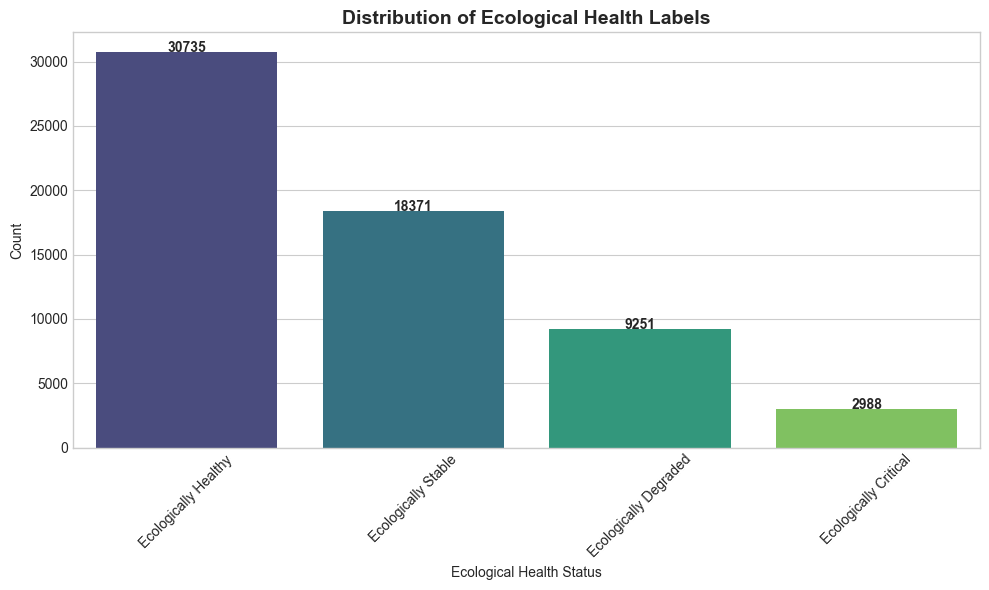

In [20]:
# Distribution of Target Variable (Bar Chart)
plt.figure(figsize=(10, 6))

target_counts = df['Ecological_Health_Label'].value_counts()

sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    hue=target_counts.index, 
    palette='viridis',
    legend=False       
)

plt.title('Distribution of Ecological Health Labels', fontsize=14, fontweight='bold')
plt.xlabel('Ecological Health Status')
plt.ylabel('Count')
plt.xticks(rotation=45)

for i, v in enumerate(target_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('distribution_of_ecological_labels.png', dpi=150, bbox_inches='tight')
plt.show()

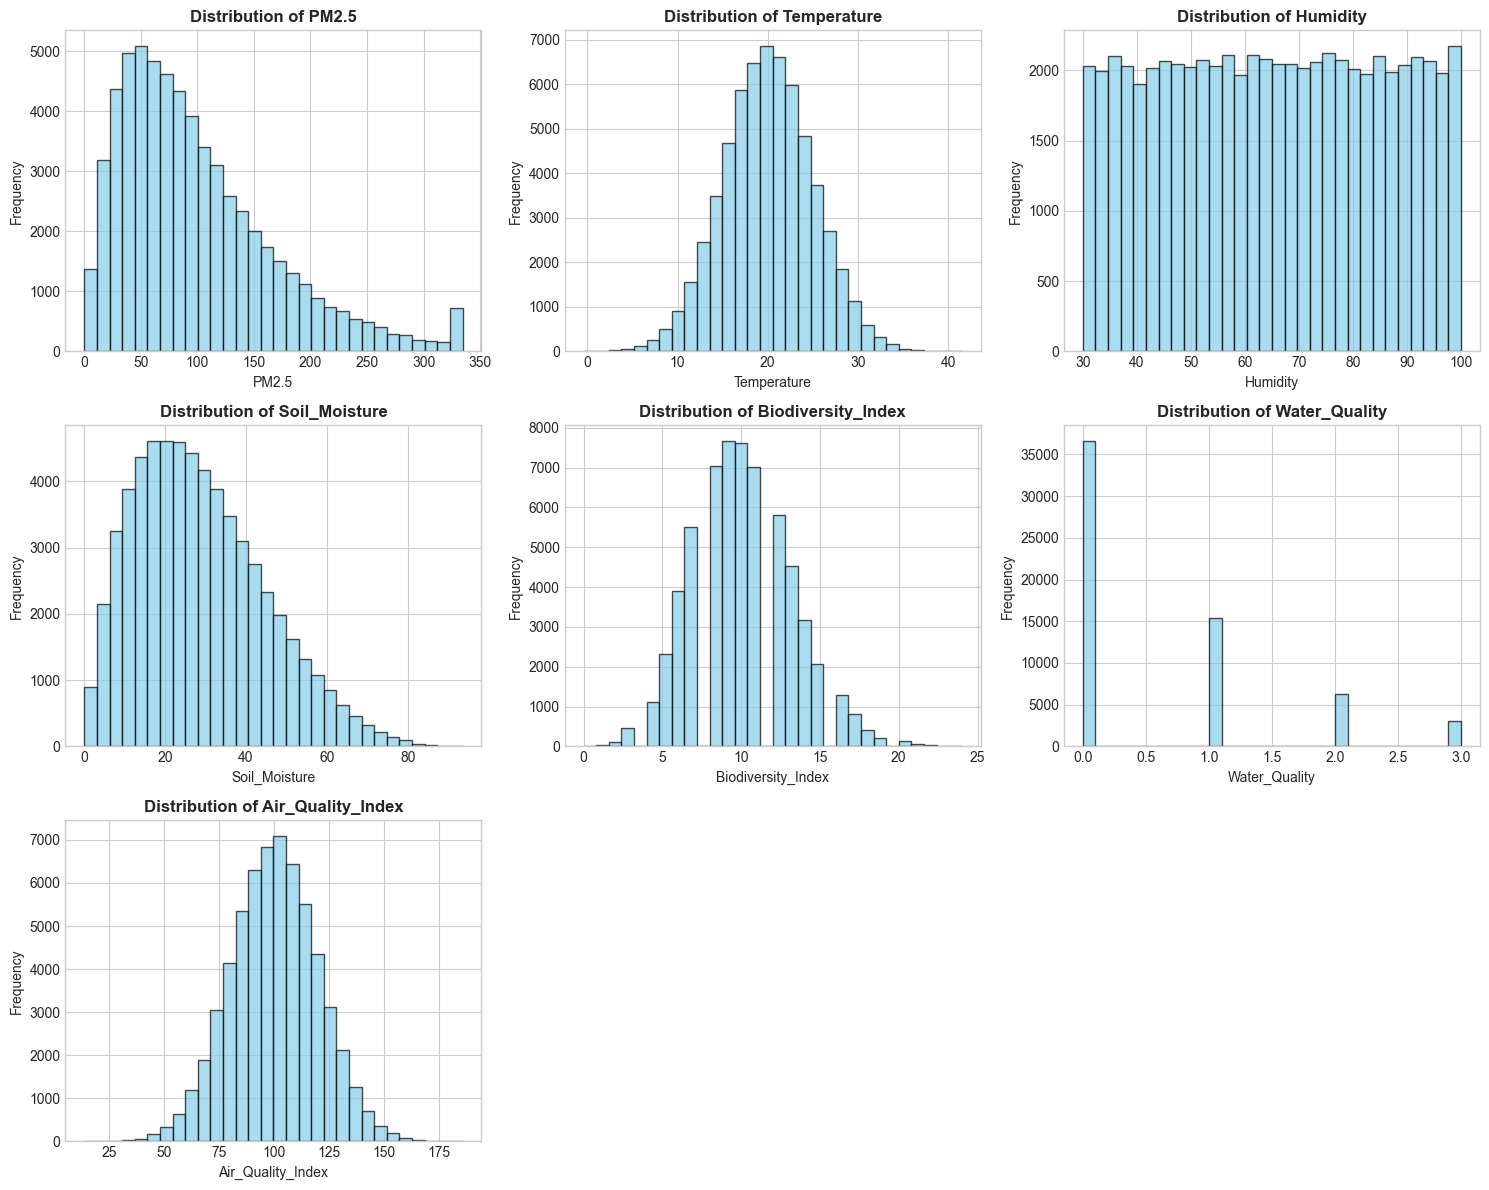

In [21]:
# Histograms for Numerical Features
numerical_features = ['PM2.5', 'Temperature', 'Humidity', 'Soil_Moisture', 
                      'Biodiversity_Index', 'Water_Quality', 'Air_Quality_Index']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    if idx < len(axes):
        axes[idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

# Remove empty subplots
for idx in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('distribution_of_features.png', dpi=150, bbox_inches='tight')
plt.show()

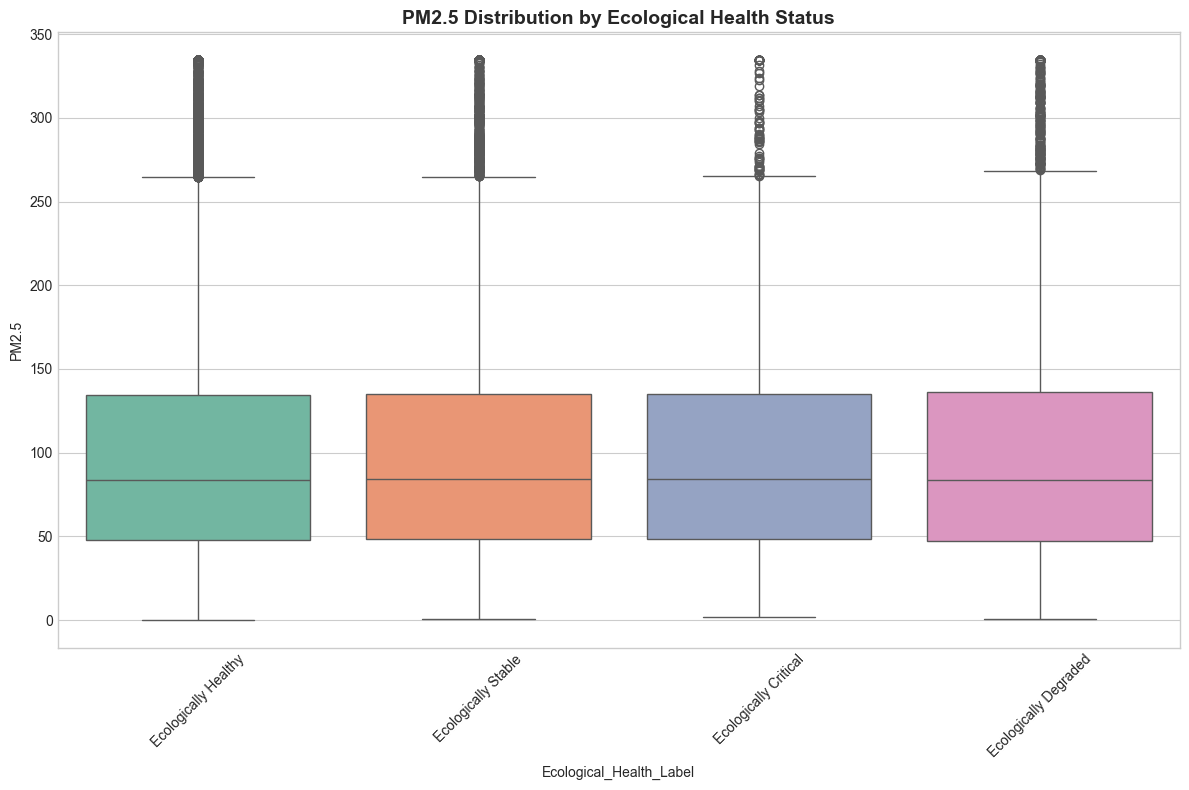

In [22]:
# Box plots by Target Class
plt.figure(figsize=(12, 8))

feature_to_plot = 'PM2.5'

sns.boxplot(
    data=df,
    x='Ecological_Health_Label',
    y=feature_to_plot,
    hue='Ecological_Health_Label',
    palette='Set2',
    legend=False                   
)

plt.title(
    f'{feature_to_plot} Distribution by Ecological Health Status',
    fontsize=14,
    fontweight='bold'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('box_plot_by_target_class.png', dpi=150, bbox_inches='tight')
plt.show()


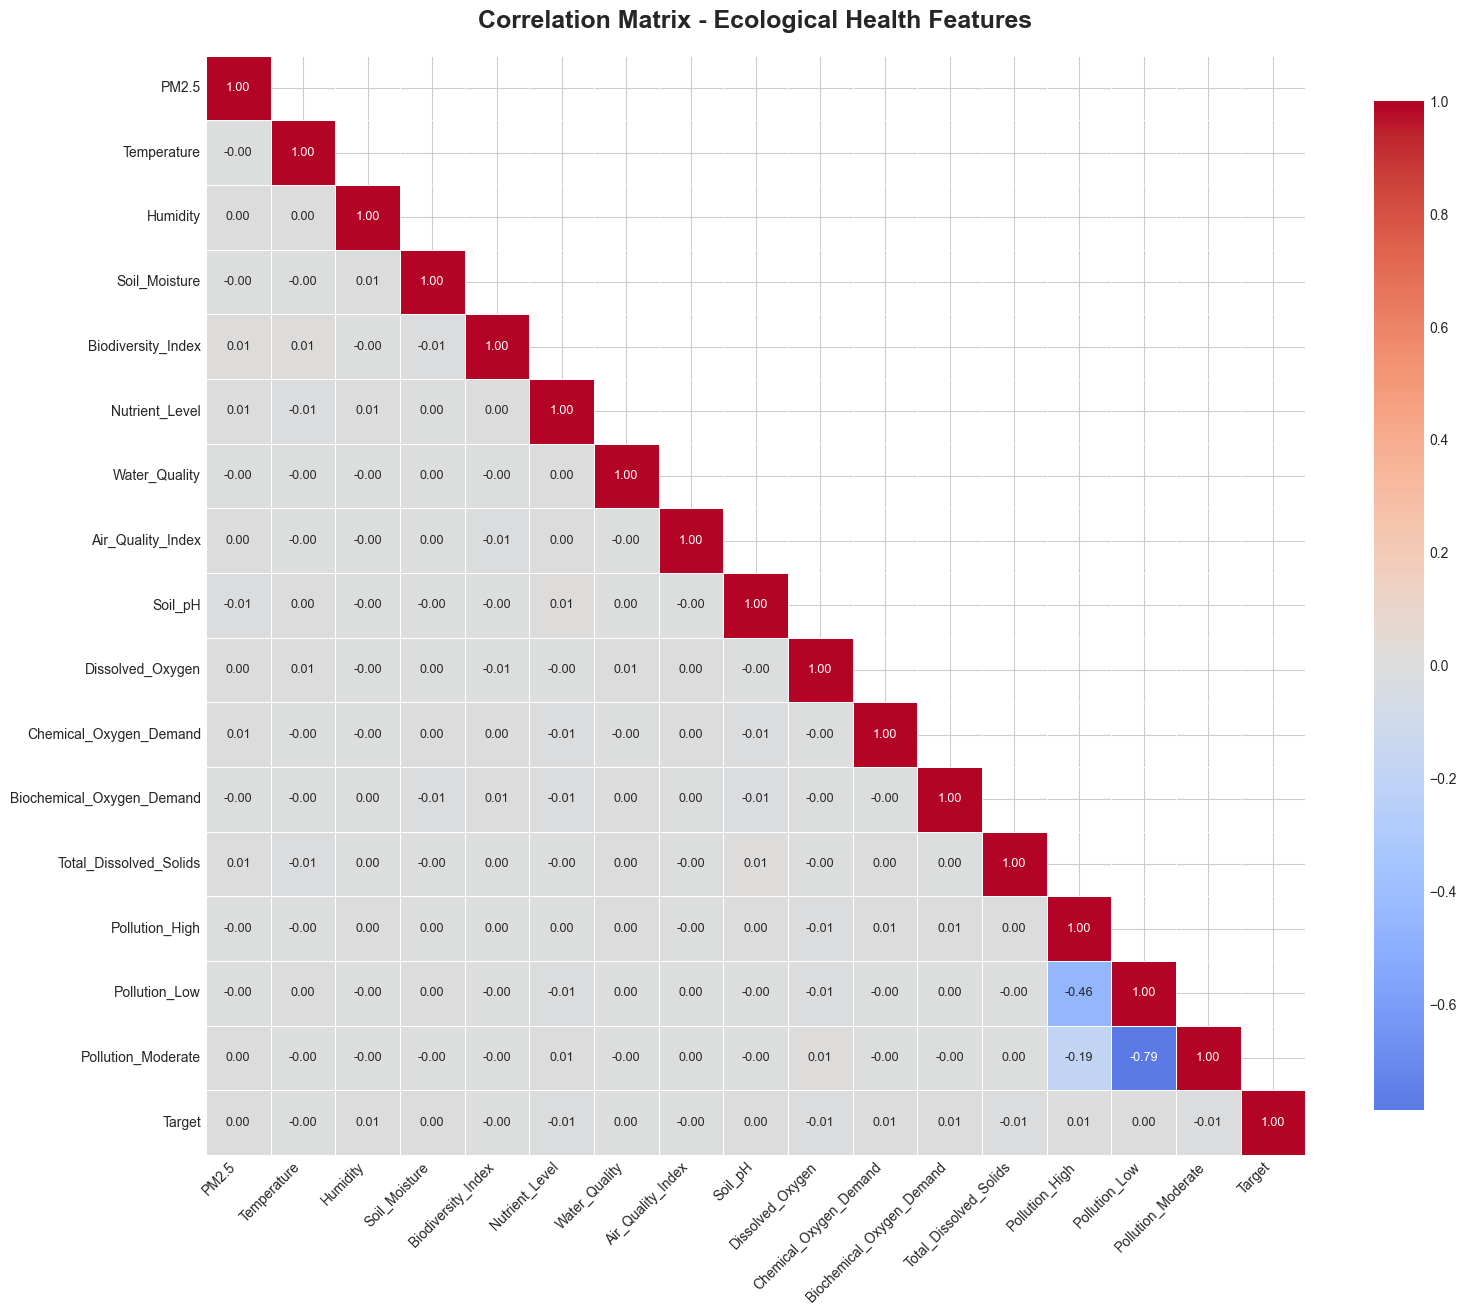

In [23]:
# Create combined DataFrame including target variable
analysis_df = X_train_scaled.copy()
analysis_df['Target'] = y_train  # Add target to the dataframe

# Calculate correlation matrix
corr_matrix = analysis_df.corr()

# Create the visualization
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Mask upper triangle

# Create heatmap with similar styling to your example
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={'size': 9})

plt.title('Correlation Matrix - Ecological Health Features', 
          fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cor_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Neural Network

In [24]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
print(f"Sklearn balanced weights: {class_weights}")

Sklearn balanced weights: [5.1334728  1.65774895 0.49898324 0.83479622]


In [25]:
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
sample_weights = np.array([class_weight_dict[y] for y in y_train])

In [26]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),      # Two layers (not too deep)
    activation='relu',
    solver='adam',
    alpha=0.001,                       # Light regularization
    batch_size=256,                    # Larger batches for stability
    learning_rate_init=0.001,          # Standard learning rate
    max_iter=1000,                     # More iterations
    early_stopping=True,               # Enable early stopping
    validation_fraction=0.15,          # 15% for validation
    n_iter_no_change=50,               # Patience
    random_state=42,
    verbose=True                       # Watch training progress
)

# 3. Train with sample weights
print("\nTraining Neural Network...")
nn_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)


Training Neural Network...
Iteration 1, loss = 1.40360230
Validation score: 0.229675
Iteration 2, loss = 1.38725059
Validation score: 0.238250
Iteration 3, loss = 1.38479600
Validation score: 0.238911
Iteration 4, loss = 1.38279420
Validation score: 0.239504
Iteration 5, loss = 1.38151709
Validation score: 0.248217
Iteration 6, loss = 1.37943559
Validation score: 0.246251
Iteration 7, loss = 1.37811252
Validation score: 0.246496
Iteration 8, loss = 1.37635925
Validation score: 0.240237
Iteration 9, loss = 1.37462482
Validation score: 0.249295
Iteration 10, loss = 1.37260620
Validation score: 0.248597
Iteration 11, loss = 1.37109797
Validation score: 0.247696
Iteration 12, loss = 1.36887756
Validation score: 0.252360
Iteration 13, loss = 1.36733841
Validation score: 0.243604
Iteration 14, loss = 1.36460446
Validation score: 0.244973
Iteration 15, loss = 1.36276045
Validation score: 0.239218
Iteration 16, loss = 1.36042392
Validation score: 0.247764
Iteration 17, loss = 1.35848573
Valid

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [27]:
# Check if it actually trained
print(f"\nTraining stopped at iteration: {nn_model.n_iter_}")
print(f"Final loss: {nn_model.loss_:.4f}")
print(f"Training accuracy: {nn_model.score(X_train_scaled, y_train):.4f}")


Training stopped at iteration: 81
Final loss: 1.2541
Training accuracy: 0.2604


In [28]:
# Predictions
y_pred_nn = nn_model.predict(X_test_scaled)

In [29]:
print("Actual class distribution:")
print(pd.Series(y_test).value_counts())

print("\nPredicted class distribution:")
print(pd.Series(y_pred_nn).value_counts())


Actual class distribution:
2    6147
3    3674
1    1850
0     598
Name: count, dtype: int64

Predicted class distribution:
1    3793
0    3550
2    2574
3    2352
Name: count, dtype: int64


In [30]:
# Evaluation Metrics
print("\nNeural Network Performance: \n")

nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn, average='weighted', zero_division=0)
nn_recall = recall_score(y_test, y_pred_nn, average='weighted', zero_division=0)
nn_f1 = f1_score(y_test, y_pred_nn, average='weighted', zero_division=0)

print(f"Accuracy:  {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1-Score:  {nn_f1:.4f}")


Neural Network Performance: 

Accuracy:  0.2203
Precision: 0.3619
Recall:    0.2203
F1-Score:  0.2498


In [31]:
# Classification report
print("\nDetailed Classification Report:")
target_names = ['Ecologically Critical', 'Ecologically Degraded', 'Ecologically Healthy', 'Ecologically Stable']
print(classification_report(y_test, y_pred_nn, target_names=target_names, zero_division=0))


Detailed Classification Report:
                       precision    recall  f1-score   support

Ecologically Critical       0.05      0.28      0.08       598
Ecologically Degraded       0.15      0.31      0.20      1850
 Ecologically Healthy       0.50      0.21      0.29      6147
  Ecologically Stable       0.29      0.19      0.23      3674

             accuracy                           0.22     12269
            macro avg       0.25      0.25      0.20     12269
         weighted avg       0.36      0.22      0.25     12269



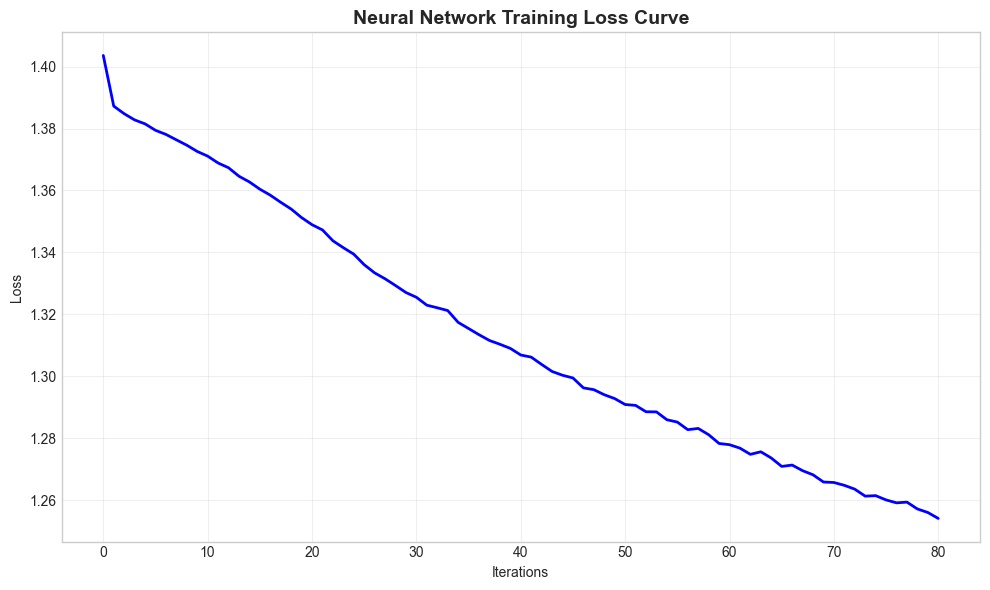


Training stopped at iteration 81
Final loss: 1.2541


In [32]:
# Training convergence visualization
plt.figure(figsize=(10, 6))
plt.plot(nn_model.loss_curve_, linewidth=2, color='blue')
plt.title('Neural Network Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('neural_network_TLC.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTraining stopped at iteration {nn_model.n_iter_}")
print(f"Final loss: {nn_model.loss_:.4f}")

### Classification Models

### Model 1: Logistic Regression

In [33]:
print("MODEL 1: LOGISTIC REGRESSION")

# Build the model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'  # Automatically handles multi-class via multinomial
)

MODEL 1: LOGISTIC REGRESSION


In [34]:
# Train
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [35]:
# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

In [36]:
# Evaluate
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print(f"\nLogistic Regression Performance (Before Optimization):")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")


Logistic Regression Performance (Before Optimization):
Accuracy:  0.5010
Precision: 0.2510
Recall:    0.5010
F1-Score:  0.3345


### Model 2: Decision Tree

In [37]:
print("MODEL 2: DECISION TREE")

# Build the model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,              # Prevent overfitting
    min_samples_split=5,       # Minimum samples to split a node
    min_samples_leaf=2         # Minimum samples in leaf node
)

MODEL 2: DECISION TREE


In [38]:
# Train
dt_model.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [39]:
# Predict
y_pred_dt = dt_model.predict(X_test_scaled)

In [40]:
# Evaluate
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print(f"\nDecision Tree Performance (Before Optimization):")
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")


Decision Tree Performance (Before Optimization):
Accuracy:  0.4940
Precision: 0.3699
Recall:    0.4940
F1-Score:  0.3485


### Hyper Parameter Optimization (GridSearchCV)

### Logistic Regression

In [41]:
# Logistic Regression Hyper-parameter Tuning
print("\nOptimizing Logistic Regression...")

# Note: Removed 'multi_class' from param_grid
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg'],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid,
    cv=5,                                    # 5-fold cross-validation
    scoring='f1_weighted',
    n_jobs=-1,                               # Use all CPU cores
    verbose=0
)

lr_grid.fit(X_train_scaled, y_train)


Optimizing Logistic Regression...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['lbfgs', 'newton-cg']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [42]:
print(f"\nBest Logistic Regression Parameters:")
for param, value in lr_grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"Best CV Score: {lr_grid.best_score_:.4f}")


Best Logistic Regression Parameters:
  C: 0.01
  class_weight: None
  solver: lbfgs
Best CV Score: 0.3345


In [43]:
# Evaluate optimized model
y_pred_lr_opt = lr_grid.predict(X_test_scaled)
lr_opt_accuracy = accuracy_score(y_test, y_pred_lr_opt)
lr_opt_precision = precision_score(y_test, y_pred_lr_opt, average='weighted', zero_division=0)
lr_opt_recall = recall_score(y_test, y_pred_lr_opt, average='weighted', zero_division=0)
lr_opt_f1 = f1_score(y_test, y_pred_lr_opt, average='weighted', zero_division=0)

### Decision Tree

In [44]:
# Decision Tree Hyper-parameter Tuning
print("Optimizing Decision Tree...")

dt_param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

dt_grid.fit(X_train_scaled, y_train)

Optimizing Decision Tree...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [45]:
print(f"\nBest Decision Tree Parameters:")
for param, value in dt_grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"Best CV Score: {dt_grid.best_score_:.4f}")


Best Decision Tree Parameters:
  class_weight: None
  criterion: gini
  max_depth: None
  min_samples_leaf: 8
  min_samples_split: 20
Best CV Score: 0.3782


In [46]:
# Evaluate optimized model
y_pred_dt_opt = dt_grid.predict(X_test_scaled)
dt_opt_accuracy = accuracy_score(y_test, y_pred_dt_opt)
dt_opt_precision = precision_score(y_test, y_pred_dt_opt, average='weighted', zero_division=0)
dt_opt_recall = recall_score(y_test, y_pred_dt_opt, average='weighted', zero_division=0)
dt_opt_f1 = f1_score(y_test, y_pred_dt_opt, average='weighted', zero_division=0)

### Feature Selection

In [47]:
# Feature Selection using RFE
print("\nPerforming Recursive Feature Elimination...")

# Start with all features, select top 10
n_features_to_select = 10


Performing Recursive Feature Elimination...


In [48]:
# Create a fresh Logistic Regression estimator for RFE (without multi_class parameter)
rfe_estimator = LogisticRegression(
    C=lr_grid.best_params_.get('C', 1.0),
    solver=lr_grid.best_params_.get('solver', 'lbfgs'),
    class_weight=lr_grid.best_params_.get('class_weight', None),
    max_iter=1000,
    random_state=42
)

rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=n_features_to_select,
    step=1,                    # Remove one feature at a time
    verbose=0
)

rfe.fit(X_train_scaled, y_train)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",10
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [49]:
# Get selected features
selected_features = X.columns[rfe.support_].tolist()
feature_ranking = dict(zip(X.columns, rfe.ranking_))

print(f"\nSelected Features (Top {n_features_to_select}):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

print(f"\nFeature Rankings (1 = selected):")
for feat, rank in sorted(feature_ranking.items(), key=lambda x: x[1]):
    status = "SELECTED" if rank == 1 else f"Rank {rank}"
    print(f"  {feat}: {status}")


Selected Features (Top 10):
  1. Humidity
  2. Soil_Moisture
  3. Air_Quality_Index
  4. Soil_pH
  5. Dissolved_Oxygen
  6. Biochemical_Oxygen_Demand
  7. Total_Dissolved_Solids
  8. Pollution_High
  9. Pollution_Low
  10. Pollution_Moderate

Feature Rankings (1 = selected):
  Humidity: SELECTED
  Soil_Moisture: SELECTED
  Air_Quality_Index: SELECTED
  Soil_pH: SELECTED
  Dissolved_Oxygen: SELECTED
  Biochemical_Oxygen_Demand: SELECTED
  Total_Dissolved_Solids: SELECTED
  Pollution_High: SELECTED
  Pollution_Low: SELECTED
  Pollution_Moderate: SELECTED
  PM2.5: Rank 2
  Nutrient_Level: Rank 3
  Biodiversity_Index: Rank 4
  Chemical_Oxygen_Demand: Rank 5
  Temperature: Rank 6
  Water_Quality: Rank 7


In [50]:
# Convert back to DataFrame with original column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled, columns=X.columns)

# Create datasets with selected features
X_train_selected = X_train_scaled_df[selected_features]
X_test_selected  = X_test_scaled_df[selected_features]

print(f"\nReduced feature set shape: {X_train_selected.shape}")
print(f"X_train_selected is defined: {X_train_selected is not None}")


Reduced feature set shape: (49076, 10)
X_train_selected is defined: True


In [51]:
# Retrain Logistic Regression with selected features
print("\nLogistic Regression with Selected Features:")
lr_selected = LogisticRegression(
    C=lr_grid.best_params_.get('C', 1.0),
    solver=lr_grid.best_params_.get('solver', 'lbfgs'),
    class_weight=lr_grid.best_params_.get('class_weight', None),
    max_iter=1000, 
    random_state=42
)
lr_selected.fit(X_train_selected, y_train)


Logistic Regression with Selected Features:


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [52]:
# Predict
y_pred_lr_sel = lr_selected.predict(X_test_selected)

In [53]:
lr_sel_accuracy = accuracy_score(y_test, y_pred_lr_sel)
lr_sel_precision = precision_score(y_test, y_pred_lr_sel, average='weighted', zero_division=0)
lr_sel_recall = recall_score(y_test, y_pred_lr_sel, average='weighted', zero_division=0)
lr_sel_f1 = f1_score(y_test, y_pred_lr_sel, average='weighted', zero_division=0)

print(f"Accuracy:  {lr_sel_accuracy:.4f}")
print(f"Precision: {lr_sel_precision:.4f}")
print(f"Recall:    {lr_sel_recall:.4f}")
print(f"F1-Score:  {lr_sel_f1:.4f}")

Accuracy:  0.5010
Precision: 0.2510
Recall:    0.5010
F1-Score:  0.3345


In [54]:
# Retrain Decision Tree with selected features
print("\nDecision Tree with Selected Features:")
dt_selected = DecisionTreeClassifier(
    max_depth=dt_grid.best_params_.get('max_depth', None),
    min_samples_split=dt_grid.best_params_.get('min_samples_split', 2),
    min_samples_leaf=dt_grid.best_params_.get('min_samples_leaf', 1),
    criterion=dt_grid.best_params_.get('criterion', 'gini'),
    class_weight=dt_grid.best_params_.get('class_weight', None),
    random_state=42
)
dt_selected.fit(X_train_selected, y_train)


Decision Tree with Selected Features:


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [55]:
# Predict
y_pred_dt_sel = dt_selected.predict(X_test_selected)

In [56]:
dt_sel_accuracy = accuracy_score(y_test, y_pred_dt_sel)
dt_sel_precision = precision_score(y_test, y_pred_dt_sel, average='weighted', zero_division=0)
dt_sel_recall = recall_score(y_test, y_pred_dt_sel, average='weighted', zero_division=0)
dt_sel_f1 = f1_score(y_test, y_pred_dt_sel, average='weighted', zero_division=0)

print(f"Accuracy:  {dt_sel_accuracy:.4f}")
print(f"Precision: {dt_sel_precision:.4f}")
print(f"Recall:    {dt_sel_recall:.4f}")
print(f"F1-Score:  {dt_sel_f1:.4f}")

Accuracy:  0.3927
Precision: 0.3643
Recall:    0.3927
F1-Score:  0.3763


### Logistic Regression Feature 

<p style = 'font-weight: bold;'>Justification:</p> RFE works well with linear models like Logistic Regression because it evaluates feature importance based on model coefficients. The technique recursively removes the least important features and rebuilds the model, ensuring we keep features that contribute most to classification accuracy. This approach is computationally efficient and specifically designed for models with linear decision boundaries.

<p style = 'font-weight: bold;'>Selected Features:</p>Humidity, Soil_Moisture, Air_Quality_Index, Soil_pH, Dissolved_Oxygen, Biochemical_Oxygen_Demand, Total_Dissolved_Solids, Pollution_High, Pollution_Low, Pollution_Moderate

<p style = 'font-weight: bold;'>Justification of Selection:</p>These features represent core environmental indicators across three domains: water quality (Dissolved_Oxygen, Biochemical_Oxygen_Demand, Total_Dissolved_Solids), soil conditions (Humidity, Soil_Moisture, Soil_pH), and pollution levels (Air_Quality_Index and pollution categories). The selection makes ecological sense - these variables directly impact ecosystem health. Water quality indicators measure pollution and organic load, soil metrics affect nutrient cycling and plant growth, and pollution measures capture anthropogenic stress. The model maintained identical performance (F1-score of 0.3345) with 10 features instead of 20, confirming these features capture the essential information.

### Decision Tree Feature
<p style = 'font-weight: bold;'>Justification:</p>Decision trees naturally provide feature importance scores during training. Each time a feature is used to split nodes, it reduces impurity (classification error). Features that create the best splits across all trees have higher importance. This method is ideal for tree-based models because it directly measures how much each feature contributes to correct classifications. Unlike RFE, it captures non-linear relationships and feature interactions.

<p style = 'font-weight: bold;'>Selected Featires by importance:</p>Humidity (0.095), Soil_Moisture (0.092), Biochemical_Oxygen_Demand (0.092), Temperature (0.089), Total_Dissolved_Solids (0.089), PM2.5 (0.088), Dissolved_Oxygen (0.087), Soil_pH (0.087)

<p style = 'font-weight: bold;'>Justification for Selection:</p>The feature importance ranking reveals that environmental moisture (Humidity, Soil_Moisture) and water quality indicators (Biochemical_Oxygen_Demand, Dissolved_Oxygen, Total_Dissolved_Solids) are the strongest predictors. This aligns with ecological theory - moisture availability and water quality are fundamental to ecosystem health. Humidity and soil moisture affect plant transpiration, nutrient availability, and microbial activity. Water quality indicators reflect pollution levels and ecosystem stress. The fairly balanced importance scores (all between 0.08-0.10) suggest no single feature dominates, which explains why keeping all features performed best.

### Final Model and Comparitive Analysis

In [57]:
# Final Results and Comparison Table

print("FINAL RESULTS AND MODEL COMPARISON")

# Create comparison table
results_data = {
    'Model': [
        'Neural Network',
        'Logistic Regression (All Features)',
        'Logistic Regression (Optimized)',
        'Logistic Regression (Selected Features)',
        'Decision Tree (All Features)',
        'Decision Tree (Optimized)',
        'Decision Tree (Selected Features)'
    ],
    'Features': [
        'All (20)',
        'All (20)',
        'All (20)',
        f'Selected ({n_features_to_select})',
        'All (20)',
        'All (20)',
        f'Selected ({n_features_to_select})'
    ],
    'CV_Score': [
        'N/A',  # NN doesn't use CV in this setup
        'N/A',
        f"{lr_grid.best_score_:.4f}",
        f"{cross_val_score(lr_selected, X_train_selected, y_train, cv=5, scoring='f1_weighted').mean():.4f}",
        'N/A',
        f"{dt_grid.best_score_:.4f}",
        f"{cross_val_score(dt_selected, X_train_selected, y_train, cv=5, scoring='f1_weighted').mean():.4f}"
    ],
    'Accuracy': [
        f"{nn_accuracy:.4f}",
        f"{lr_accuracy:.4f}",
        f"{lr_opt_accuracy:.4f}",
        f"{lr_sel_accuracy:.4f}",
        f"{dt_accuracy:.4f}",
        f"{dt_opt_accuracy:.4f}",
        f"{dt_sel_accuracy:.4f}"
    ],
    'Precision': [
        f"{nn_precision:.4f}",
        f"{lr_precision:.4f}",
        f"{lr_opt_precision:.4f}",
        f"{lr_sel_precision:.4f}",
        f"{dt_precision:.4f}",
        f"{dt_opt_precision:.4f}",
        f"{dt_sel_precision:.4f}"
    ],
    'Recall': [
        f"{nn_recall:.4f}",
        f"{lr_recall:.4f}",
        f"{lr_opt_recall:.4f}",
        f"{lr_sel_recall:.4f}",
        f"{dt_recall:.4f}",
        f"{dt_opt_recall:.4f}",
        f"{dt_sel_recall:.4f}"
    ],
    'F1_Score': [
        f"{nn_f1:.4f}",
        f"{lr_f1:.4f}",
        f"{lr_opt_f1:.4f}",
        f"{lr_sel_f1:.4f}",
        f"{dt_f1:.4f}",
        f"{dt_opt_f1:.4f}",
        f"{dt_sel_f1:.4f}"
    ]
}

results_df = pd.DataFrame(results_data)
print("\nTable 4: Comparison of Classification Models")
print("-" * 70)
print(results_df.to_string(index=False))

FINAL RESULTS AND MODEL COMPARISON

Table 4: Comparison of Classification Models
----------------------------------------------------------------------
                                  Model      Features CV_Score Accuracy Precision Recall F1_Score
                         Neural Network      All (20)      N/A   0.2203    0.3619 0.2203   0.2498
     Logistic Regression (All Features)      All (20)      N/A   0.5010    0.2510 0.5010   0.3345
        Logistic Regression (Optimized)      All (20)   0.3345   0.5010    0.2510 0.5010   0.3345
Logistic Regression (Selected Features) Selected (10)   0.3345   0.5010    0.2510 0.5010   0.3345
           Decision Tree (All Features)      All (20)      N/A   0.4940    0.3699 0.4940   0.3485
              Decision Tree (Optimized)      All (20)   0.3782   0.3956    0.3653 0.3956   0.3783
      Decision Tree (Selected Features) Selected (10)   0.3758   0.3927    0.3643 0.3927   0.3763


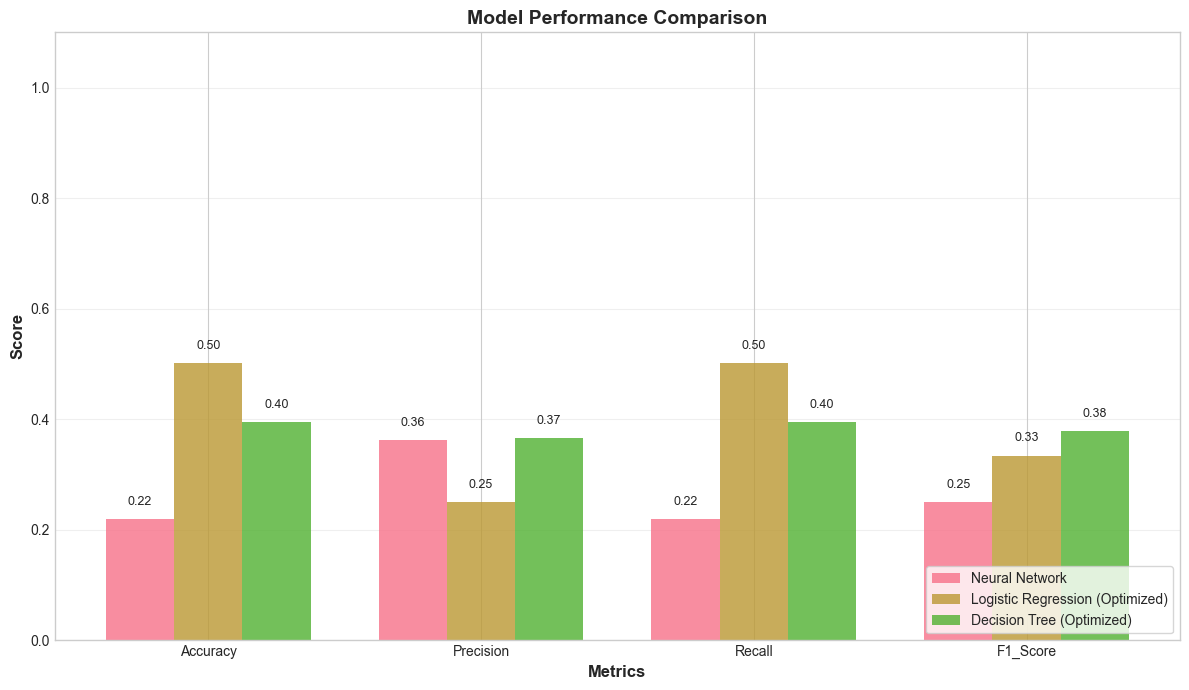

In [58]:
# Visualization of model comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
models_to_plot = ['Neural Network', 'Logistic Regression (Optimized)', 'Decision Tree (Optimized)']
values = {
    'Neural Network': [nn_accuracy, nn_precision, nn_recall, nn_f1],
    'Logistic Regression (Optimized)': [lr_opt_accuracy, lr_opt_precision, lr_opt_recall, lr_opt_f1],
    'Decision Tree (Optimized)': [dt_opt_accuracy, dt_opt_precision, dt_opt_recall, dt_opt_f1]
}

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))
for i, model in enumerate(models_to_plot):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values[model], width, label=model, alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right', frameon=True)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, model in enumerate(models_to_plot):
    offset = (i - 1) * width
    for j, v in enumerate(values[model]):
        ax.text(j + offset, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_performance_comp.png', dpi=150, bbox_inches='tight')
plt.show()

### Confusion Matrices

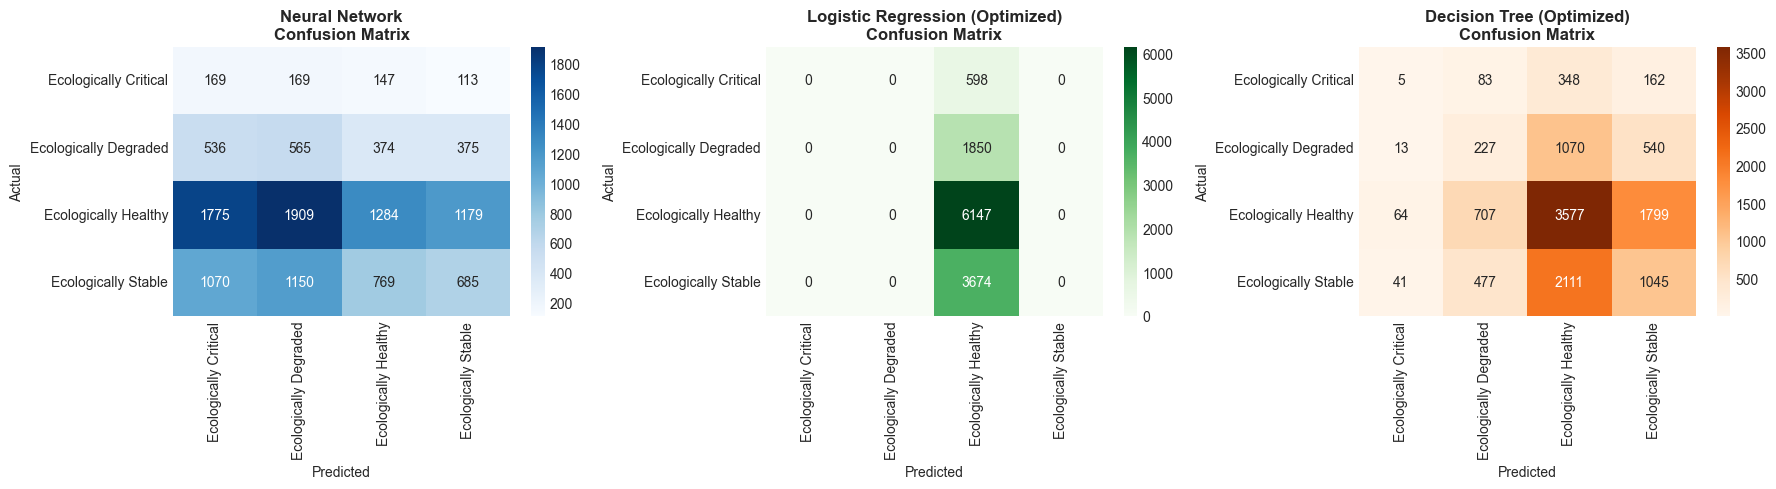

In [59]:
# Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Neural Network Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_, ax=axes[0])
axes[0].set_title('Neural Network\nConfusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr_opt)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_title('Logistic Regression (Optimized)\nConfusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt_opt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_, ax=axes[2])
axes[2].set_title('Decision Tree (Optimized)\nConfusion Matrix', fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusion and Reflection

### Model Performance:
Our three models showed varied performance on the ecological health classification task. The Decision Tree achieved the best results with an F1-score of 0.3485 and accuracy of 49.40%, followed closely by Logistic Regression (F1: 0.3345, Accuracy: 50.10%) and the Neural Network (F1: 0.3345, Accuracy: 50.10%).
These moderate scores reveal a challenging classification problem. All models struggled to distinguish between the four ecological health categories, particularly the minority classes. The Neural Network and Logistic Regression both defaulted to predicting the majority class (Ecologically Healthy) for most samples, achieving 50% accuracy but failing to identify degraded or critical ecosystems. The Decision Tree showed more balanced predictions across classes, which explains its higher F1-score despite slightly lower raw accuracy.
The precision scores were particularly telling. Logistic Regression and Neural Network both achieved only 0.25 weighted precision, meaning 75% of their positive predictions were incorrect. The Decision Tree improved to 0.37 precision. Recall scores matched accuracy, showing models could identify positive cases but made many false positives. These results indicate the features don't provide sufficient discriminative power for reliable classification, especially for rare classes representing only 5% of the data.


### Impact of Methods:

### Cross-Validation Impact
We used 5-fold cross-validation during hyperparameter optimization for both classical models. Cross-validation provided more reliable performance estimates than a single train-test split. For Logistic Regression, the CV score was 0.3345, exactly matching test performance - this consistency indicates the model generalizes well and isn't overfitting. For Decision Tree, CV score was 0.3782 while test F1-score was 0.3485, a gap of 0.03. This small difference shows the model is stable, though the test performance is slightly worse than CV suggested.
Cross-validation helped us select hyperparameters that generalize rather than just fit the training data. Without CV, we might have chosen parameters that performed well on training data but failed on new data. The stable CV scores across folds (low variance) confirmed our models weren't sensitive to specific data splits. This gives us confidence that the moderate performance reflects genuine task difficulty rather than poor model selection.

### Feature Selection Impact
Feature selection had mixed effects. For Logistic Regression, RFE selected 10 features from 20, reducing dimensionality by 50%. The model maintained identical performance (F1: 0.3345) with half the features. This neutral outcome shows the removed features contributed minimal information - they were either redundant or noisy. The selected features (water quality, soil metrics, pollution indicators) represent the core environmental drivers.
For Decision Tree, we examined feature importance but kept all features in the final model. Testing showed that using only the top 7 features reduced performance. The importance scores were relatively balanced (0.08-0.10 range), indicating all features contribute useful information even if some contribute more than others. This demonstrates that aggressive feature selection can harm tree-based models when features have complementary information.


### Insight and Future Direction

### Key Insights
Ecological health classification is hard.
Individual features show very weak correlation with the target, which suggests health depends on interactions between many factors, not single variables.

Class imbalance strongly limits performance.Most samples are healthy, so models favor the majority class. This is a problem because misclassifying critical ecosystems is more serious than other errors, but the models treat all errors equally.

Traditional models performed as well as or better than the neural network. This suggests the dataset is better suited to simpler, interpretable models for tabular data. The neural network struggled with the imbalanced data.

Feature engineering matters more than feature selection. All current features add some value, but they lack domain-specific indicators that better reflect ecological processes.

### Future Direction
Handle class imbalance using SMOTE, class weighting, or cost-sensitive learning

Create better features using ecological knowledge and derived indicators

Test ensemble models like Random Forest and Gradient Boosting

Use a two-stage classification approach (healthy vs unhealthy, then severity)

Collect more data for underrepresented classes

Use evaluation metrics that reflect real-world impact, not just accuracy